# 7. tēma — datu analīze un vizualizācija

[![Atvērt Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ValRCS/RTU_BDAA_Course_2026/blob/main/notebooks/lecture_07_data_analysis_visualization/07_data_analysis_visualization.ipynb)

Turpinām 6. lekcijā sākto SS.com dzīvokļu sludinājumu projektu:

**SS.com → scraping → CSV → Pandas → tīrīšana → analīze → Matplotlib → secinājumi → tīrs CSV**

Mērķi: pārbaudīt datu kvalitāti, konvertēt tipus, filtrēt un kārtot, lietot `groupby()`/`agg()`, veidot histogrammas, stabiņu diagrammas, scatter plot un boxplot, atrast neparastus ierakstus un izveidot atkārtojamu tīrīšanas procesu.

## 0. Darba vide

Notebook paredzēts **Run All** gan VS Code, gan Google Colab.

**Lokāli:** klonējiet repozitoriju, izveidojiet virtuālo vidi un instalējiet:
```bash
python -m pip install jupyter ipykernel pandas matplotlib plotly
```
VS Code nepieciešami Python un Jupyter paplašinājumi; izvēlieties atbilstošo Python kernel.

**Colab:** atveriet ar pogu augšā un izvēlieties *Runtime → Run all*. Ja Lecture 6 CSV lokāli nav atrodams, notebook pats nolasa to no GitHub.

Nākamā šūna instalē tikai trūkstošās pakotnes.

In [2]:
import importlib.util, subprocess, sys
packages = {"pandas":"pandas", "matplotlib":"matplotlib", "plotly":"plotly"}
missing = [pip for module,pip in packages.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
print("Vide gatava.")

Vide gatava.


## 1. Importi un datu ielāde

Vispirms mēģinām atrast `apartment_ads.csv` klonētajā repozitorijā. Colab vai citā mapē izmantojam stabilu GitHub RAW adresi. Tādējādi analīzes kods pēc ielādes abās vidēs ir identisks.

In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DATA_URL = ("https://raw.githubusercontent.com/ValRCS/RTU_BDAA_Course_2026/"
            "main/notebooks/lecture_06_web_scraping/data/ss_flats_riga_centre_sell_20260916_190746.csv")
# DATA_URL = ("https://raw.githubusercontent.com/ValRCS/RTU_BDAA_Course_2026/"
#             "main/notebooks/lecture_06_web_scraping/apartment_ads.csv")
candidates = [
    Path("../lecture_06_web_scraping/data/ss_flats_riga_centre_sell_20260916_190746.csv"),
    Path("../lecture_06_web_scraping/apartment_ads.csv"),
    Path("notebooks/lecture_06_web_scraping/apartment_ads.csv"),
    Path("apartment_ads.csv"),
]
local = next((p for p in candidates if p.exists()), None)
source = local if local is not None else DATA_URL
raw_df = pd.read_csv(source)
print("Avots:", source)
print("Forma:", raw_df.shape)

Avots: ..\lecture_06_web_scraping\data\ss_flats_riga_centre_sell_20260916_190746.csv
Forma: (872, 9)


In [5]:
# pragmātiski ja ar ceļiem varam iekopēt failu tajā pat mapē kur piezīmju grāmata
# tad atvēršanai pietiek ar pašu failu
df_same_data = pd.read_csv("ss_flats_riga_centre_sell_20260916_190746.csv")
# forma
print("Forma:", df_same_data.shape)
# vai vienāds saturs?
print("Vai vienāds saturs?", df_same_data.equals(raw_df))

Forma: (872, 9)
Vai vienāds saturs? True


## 2. Pirmā apskate un kvalitātes pārbaude

Pirms tīrīšanas neko nemainām. `head()`, `sample()`, `info()` un `isna()` palīdz saprast, ko patiesībā ieguvām. Papildus pārbaudām sagaidāmo shēmu un dublētus URL — CSV veiksmīga atvēršana vēl negarantē korektus scraping datus.

In [6]:
expected = {"url","description","Street","R.","m²","Floor","Series","Price, m2","Price"}
missing_cols = expected - set(raw_df.columns)
if missing_cols:
    raise ValueError("Trūkst kolonnu: " + ", ".join(sorted(missing_cols)))

display(raw_df.head())
display(raw_df.sample(min(5,len(raw_df)), random_state=42))
raw_df.info()
display(raw_df.isna().sum().to_frame("missing"))
print("Dublēti URL:", raw_df.duplicated(subset=["url"]).sum())
display(raw_df[["Price, m2","Price"]].head(10))

,description,url,Street,R.,m²,Floor,Series,"Price, m2",Price
0,"Vieta, vieta, vieta. Tiek pārdots dzīvoklis ēk...",https://www.ss.com/msg/en/real-estate/flats/ri...,Brivibas 19,4,94,5/6,Pre-war house,"2,122 €","199,500 €"
1,Balkons. Renovētā ēkā Rīgas centrā pārdod 4 is...,https://www.ss.com/msg/en/real-estate/flats/ri...,Stabu 16,4,109,4/6,Recon.,"1,702 €","185,500 €"
2,Trīsistabu dzīvoklis skaisti renovētā ēkā\r\n\...,https://www.ss.com/msg/en/real-estate/flats/ri...,Matisa 101,3,37,1/3,Recon.,"2,288 €","84,640 €"
3,Piedāvājumā dzīvokļi unikālā koncepta projektā...,https://www.ss.com/msg/en/real-estate/flats/ri...,Gertrudes 110,3,49,3/5,Recon.,"1,568 €","76,850 €"
4,Pārdod gaišu un plašu 2 istabu dzīvokli (54 m²...,https://www.ss.com/msg/en/real-estate/flats/ri...,Valdemara 147k-1,2,54,5/5,Spec. pr.,"1,850 €","99,900 €"


,description,url,Street,R.,m²,Floor,Series,"Price, m2",Price
794,Ekskluzīvs 3 līmeņu dzīvoklis 249 m2 platībā A...,https://www.ss.com/msg/en/real-estate/flats/ri...,Eksporta 8,5,249,2/3,Recon.,"1,968 €","490,000 €"
319,Projekts ar vēsturisku eleganci un izcilu lokā...,https://www.ss.com/msg/en/real-estate/flats/ri...,Brivibas 138,4,97,5/3,Pre-war house,"1,497 €","145,200 €"
382,"Kompāniju grupa R. Evolution, projekta attīstī...",https://www.ss.com/msg/en/real-estate/flats/ri...,Strelnieku 5,3,108,3/7,New,"4,722 €","510,000 €"
779,Īpašnieks pārdod renovētu divistabu dzīvokli p...,https://www.ss.com/msg/en/real-estate/flats/ri...,Marijas 8,2,53,3/5,Recon.,"2,536 €","134,420 €"
422,Piedāvājumā 3 istabu dzīvokli (divas izolētas ...,https://www.ss.com/msg/en/real-estate/flats/ri...,Gertrudes 43,3,71,4/5,Pre-war house,"2,324 €","165,000 €"


<class 'pandas.DataFrame'>
RangeIndex: 872 entries, 0 to 871
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   description  872 non-null    str  
 1   url          872 non-null    str  
 2   Street       872 non-null    str  
 3   R.           872 non-null    str  
 4   m²           872 non-null    int64
 5   Floor        872 non-null    str  
 6   Series       872 non-null    str  
 7   Price, m2    872 non-null    str  
 8   Price        872 non-null    str  
dtypes: int64(1), str(8)
memory usage: 61.4 KB


,missing
description,0
url,0
Street,0
R.,0
m²,0
Floor,0
Series,0
"Price, m2",0
Price,0


Dublēti URL: 0


,"Price, m2",Price
0,"2,122 €","199,500 €"
1,"1,702 €","185,500 €"
2,"2,288 €","84,640 €"
3,"1,568 €","76,850 €"
4,"1,850 €","99,900 €"
5,"1,348 €","120,000 €"
6,"1,253 €","109,000 €"
7,"3,233 €","485,000 €"
8,"2,919 €","108,000 €"
9,"1,146 €","47,000 €"


In [7]:
# ar .info mēs redzam kolonu tipus
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 872 entries, 0 to 871
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   description  872 non-null    str  
 1   url          872 non-null    str  
 2   Street       872 non-null    str  
 3   R.           872 non-null    str  
 4   m²           872 non-null    int64
 5   Floor        872 non-null    str  
 6   Series       872 non-null    str  
 7   Price, m2    872 non-null    str  
 8   Price        872 non-null    str  
dtypes: int64(1), str(8)
memory usage: 61.4 KB


In [8]:
# ir vērts arī apskatīties arī vispārēju statistiku ar .describe()
raw_df.describe(include="all")

,description,url,Street,R.,m²,Floor,Series,"Price, m2",Price
count,872,872,872,872,872.000000,872,872,872,872
unique,792,872,501,7,NaN,56,10,696,570
top,Premium klases dzīvokļi Rīgas centrā – Lāčplēš...,https://www.ss.com/msg/en/real-estate/flats/ri...,Chaka 133,2,NaN,2/5,Pre-war house,"2,500 €","220,000 €"
freq,6,1,16,272,NaN,62,322,10,12
mean,NaN,NaN,NaN,NaN,79.583716,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,67.573151,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,10.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,43.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,65.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,99.000000,NaN,NaN,NaN,NaN


In [9]:
# varam arī jebkuru tabulu transponēt ar .T
raw_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
description,872,792,Premium klases dzīvokļi Rīgas centrā – Lāčplēš...,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
url,872,872,https://www.ss.com/msg/en/real-estate/flats/ri...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Street,872,501,Chaka 133,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
R.,872,7,2,272,NaN,NaN,NaN,NaN,NaN,NaN,NaN
m²,872.0,NaN,NaN,NaN,79.583716,67.573151,10.0,43.0,65.0,99.0,1000.0
Floor,872,56,2/5,62,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Series,872,10,Pre-war house,322,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"Price, m2",872,696,"2,500 €",10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,872,570,"220,000 €",12,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Kolonnu nosaukumi un datu nozīme

Analīzei izveidojam kopiju ar konsekventiem nosaukumiem. `rooms` un `area_m2` ir skaitliski lauki, `building_series` ir kategorija, bet `floor` un cenas pagaidām ir strukturēts teksts. Īpaši svarīgi: `Price` satur gan skaitli, gan mērvienību (`€/mon.`, `€/day`).

In [10]:
df = raw_df.rename(columns={
    "Street":"street", "R.":"rooms", "m²":"area_m2", "Floor":"floor",
    "Series":"building_series", "Price, m2":"price_per_m2_raw",
    "Price":"price_raw"
}).copy() # ar copy mēs izveidojam pilnu kopiju, nevis tikai skatījumu uz datiem
display(df.head(3))

,description,url,street,rooms,area_m2,floor,building_series,price_per_m2_raw,price_raw
0,"Vieta, vieta, vieta. Tiek pārdots dzīvoklis ēk...",https://www.ss.com/msg/en/real-estate/flats/ri...,Brivibas 19,4,94,5/6,Pre-war house,"2,122 €","199,500 €"
1,Balkons. Renovētā ēkā Rīgas centrā pārdod 4 is...,https://www.ss.com/msg/en/real-estate/flats/ri...,Stabu 16,4,109,4/6,Recon.,"1,702 €","185,500 €"
2,Trīsistabu dzīvoklis skaisti renovētā ēkā\r\n\...,https://www.ss.com/msg/en/real-estate/flats/ri...,Matisa 101,3,37,1/3,Recon.,"2,288 €","84,640 €"


In [ ]:
df["rooms"].head() # vienas kollonas pirmās 5 vērtības

0    4
1    4
2    3
3    3
4    2
Name: rooms, dtype: str

In [12]:
# es varu paņemt pēdejās 3
df["rooms"].tail(3) # vienas kollonas pēdējās 3 vērtības

869    1
870    3
871    1
Name: rooms, dtype: str

In [13]:
# varu teiksim 100-104 rindas
df["rooms"].iloc[100:105]

100    3
101    2
102    4
103    3
104    3
Name: rooms, dtype: str

## 4. Teksts → skaitļi un mērvienības

Cena var būt `10 €`, `10.48€` vai `1,800 €/mon.`. Tāpēc ar `astype(float)` nepietiek. Funkcija normalizē simbolus un ar regulāro izteiksmi izvelk skaitli; `errors="coerce"` problemātisku vērtību pārvērš par `NaN`.

Mērvienību glabājam atsevišķi. `35 €/day` nav tieši salīdzināms ar `650 €/mon.` — skaitlis bez mērvienības var būt maldinošs.

In [ ]:
def euro_number(s):
    x = (s.astype("string").str.replace("\u00a0"," ",regex=False)
         .str.replace("€","",regex=False).str.replace(",","",regex=False)
         .str.replace(r"\s+","",regex=True)
         .str.extract(r"([-+]?\d+(?:\.\d+)?)", expand=False))
    return pd.to_numeric(x, errors="coerce")

# šis noderīgi īres gadījumā, kad ir norādīts periods, piemēram, "€ 1 200 / month"
def price_period(v):
    t = str(v).lower()
    if "/mon" in t or "/month" in t: return "month"
    if "/day" in t: return "day"
    if "/week" in t: return "week"
    if "/year" in t: return "year"
    return "unknown"

# mēs tātad piespiedu kārtā pārvērtīsim dažas kolonnas uz skaitliskām vērtībām, lai varētu ar tām strādāt
df["rooms"] = pd.to_numeric(df["rooms"], errors="coerce").astype("Int64")
df["area_m2"] = pd.to_numeric(df["area_m2"], errors="coerce")
df["price_per_m2"] = euro_number(df["price_per_m2_raw"])
df["price_eur"] = euro_number(df["price_raw"])
df["price_period"] = df["price_raw"].apply(price_period)

display(df[["price_raw","price_eur","price_period","price_per_m2"]].head(12))
display(df["price_period"].value_counts().to_frame("listings"))

,price_raw,price_eur,price_period,price_per_m2
0,"199,500 €",199500,unknown,2122
1,"185,500 €",185500,unknown,1702
2,"84,640 €",84640,unknown,2288
3,"76,850 €",76850,unknown,1568
4,"99,900 €",99900,unknown,1850
5,"120,000 €",120000,unknown,1348
6,"109,000 €",109000,unknown,1253
7,"485,000 €",485000,unknown,3233
8,"108,000 €",108000,unknown,2919
9,"47,000 €",47000,unknown,1146


,listings
price_period,
unknown,872


In [15]:
# apskatamies tagad datu tipus
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 872 entries, 0 to 871
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   description       872 non-null    str  
 1   url               872 non-null    str  
 2   street            872 non-null    str  
 3   rooms             862 non-null    Int64
 4   area_m2           872 non-null    int64
 5   floor             872 non-null    str  
 6   building_series   872 non-null    str  
 7   price_per_m2_raw  872 non-null    str  
 8   price_raw         872 non-null    str  
 9   price_per_m2      872 non-null    Int64
 10  price_eur         872 non-null    Int64
 11  price_period      872 non-null    str  
dtypes: Int64(3), int64(1), str(8)
memory usage: 84.4 KB


## 5. `Floor` sadalīšana un feature engineering

`4/8` nozīmē “4. stāvs no 8”. No viena teksta lauka izveidojam `floor_number`, `building_floors`, `is_ground_floor` un `is_top_floor`. Šādu jaunu pazīmju veidošanu no esošiem datiem sauc par **feature engineering**.

In [16]:
parts = df["floor"].astype("string").str.extract(
    r"(?P<floor_number>\d+)\s*/\s*(?P<building_floors>\d+)")
df["floor_number"] = pd.to_numeric(parts["floor_number"], errors="coerce").astype("Int64")
df["building_floors"] = pd.to_numeric(parts["building_floors"], errors="coerce").astype("Int64")
df["is_ground_floor"] = df["floor_number"].eq(1)
df["is_top_floor"] = df["floor_number"].eq(df["building_floors"])
df["building_series"] = df["building_series"].astype("string").str.strip().astype("category")

before = len(df)
df = df.drop_duplicates(subset=["url"], keep="first").copy()
df["calculated_price_per_m2"] = df["price_eur"] / df["area_m2"]
df["price_m2_difference"] = (df["price_per_m2"]-df["calculated_price_per_m2"]).abs()
print("Noņemti dublēti URL:", before-len(df))
display(df[["floor","floor_number","building_floors","is_top_floor"]].head(10))

Noņemti dublēti URL: 0


,floor,floor_number,building_floors,is_top_floor
0,5/6,5,6,False
1,4/6,4,6,False
2,1/3,1,3,False
3,3/5,3,5,False
4,5/5,5,5,True
5,5/5,5,5,True
6,1/5,1,5,False
7,4/5,4,5,False
8,3/7,3,7,False
9,4/5,4,5,False


## 6. Salīdzināma analīzes kopa

Galvenajai analīzei izmantojam tikai **mēneša īres** sludinājumus ar svarīgākajiem skaitliskajiem laukiem. Dienas cenu automātiska reizināšana ar 30 būtu biznesa pieņēmums, nevis neitrāla tīrīšana.

Tad demonstrējam tipisko Pandas plūsmu: **filtrēšana → kārtošana → aprakstošā statistika**.

In [ ]:
# pameklēsim dzīvokļus kas ir vismaz 50 m² un cena ir zem 1500 EUR/m²
# šajā piemēra mums ir divi filtri kuriem abiem jāizpildās tāda principsa kā AND, tātad mēs izmantojam & simbolu
cheapies = df[(df["area_m2"] >= 50) & (df["price_per_m2"] < 1500)]
# cik tādi ir ?
print(f"Skaitāms dzīvokļu: {cheapies.shape[0]}")
# kārtosim pēc cenas uz m²
cheapies = cheapies.sort_values("price_per_m2")
# lētākie 10
display(cheapies.head(10))

Skaitāms dzīvokļu: 89


,description,url,street,rooms,area_m2,floor,building_series,price_per_m2_raw,price_raw,price_per_m2,price_eur,price_period,floor_number,building_floors,is_ground_floor,is_top_floor,calculated_price_per_m2,price_m2_difference
842,Pārdošanā 428 m² bēniņu telpas virs 5. stāva S...,https://www.ss.com/msg/en/real-estate/flats/ri...,Ierochu 1,1,428,5/5,Stalin project,126 €,"54,000 €",126,54000,unknown,5,5,False,True,126.168224,0.168224
686,"Mājas pirmais un otrais stāvs, atsevišķas ieej...",https://www.ss.com/msg/en/real-estate/flats/ri...,Latgales 108,<NA>,1000,1/3,Spec. pr.,165 €,"164,800 €",165,164800,unknown,1,3,True,False,164.8,0.2
687,Tiek pārdots komerctelpu komplekss kapitālā ķi...,https://www.ss.com/msg/en/real-estate/flats/ri...,Latgales 108,<NA>,1000,1/2,Spec. pr.,165 €,"164,800 €",165,164800,unknown,1,2,True,False,164.8,0.2
196,109 m² plašas pagraba telpas fantastiskā lokāc...,https://www.ss.com/msg/en/real-estate/flats/ri...,Terbatas 39,6,110,1/5,Pre-war house,250 €,"27,500 €",250,27500,unknown,1,5,True,False,250.0,0.0
806,Perspektīvs investīciju objekts Rīgas centrā a...,https://www.ss.com/msg/en/real-estate/flats/ri...,Bruninieku 89,1,235,5/5,Recon.,277 €,"65,000 €",277,65000,unknown,5,5,False,True,276.595745,0.404255
195,"Pārdodu 93 m² plašu puspagraba telpu īpašumu, ...",https://www.ss.com/msg/en/real-estate/flats/ri...,Matisa 31,<NA>,94,1/4,Pre-war house,298 €,"28,000 €",298,28000,unknown,1,4,True,False,297.87234,0.12766
571,Pārdošanā ir unikāla bēniņu telpa vēsturiskā ē...,https://www.ss.com/msg/en/real-estate/flats/ri...,Bruninieku 89,<NA>,300,6/6,Pre-war house,300 €,"89,999 €",300,89999,unknown,6,6,False,True,299.996667,0.003333
232,Matīsa ielā 93 pieejama atvērta plānojuma telp...,https://www.ss.com/msg/en/real-estate/flats/ri...,Matisa 93,2,91,5/5,Pre-war house,407 €,"37,000 €",407,37000,unknown,5,5,False,True,406.593407,0.406593
336,Tiek pārdots perspektīvs bēniņu attīstības obj...,https://www.ss.com/msg/en/real-estate/flats/ri...,Tallinas 90A,6,230,6/6,Recon.,430 €,"99,000 €",430,99000,unknown,6,6,False,True,430.434783,0.434783
132,"Siltas, sausas, saulainas augsta puspagraba te...",https://www.ss.com/msg/en/real-estate/flats/ri...,Chaka 133,4,125,1/6,Pre-war house,540 €,"67,541 €",540,67541,unknown,1,6,True,False,540.328,0.328


In [20]:
# meklēsim vai nu dārgus pēc cenas vai pēc cenas uz m², tātad šeit mums ir divi filtri kuriem jāizpildās tāda principsa kā OR, tātad mēs izmantojam | simbolu
expensive = df[(df["price_per_m2"] > 5000) | (df["price_eur"] > 500000)]
# cik tādi ir ?
print(f"Skaitāms dzīvokļu: {expensive.shape[0]}")
# sakārtosim pēc cenas uz m²
expensive = expensive.sort_values("price_per_m2")
# dārgākie 10
display(expensive.head(10))

Skaitāms dzīvokļu: 34


,description,url,street,rooms,area_m2,floor,building_series,price_per_m2_raw,price_raw,price_per_m2,price_eur,price_period,floor_number,building_floors,is_ground_floor,is_top_floor,calculated_price_per_m2,price_m2_difference
370,Elegants 4 istabu dzīvoklis ar panorāmas skatu...,https://www.ss.com/msg/en/real-estate/flats/ri...,J. Dalina 8,4,227,19/24,New,"3,040 €","690,000 €",3040,690000,unknown,19,24,False,False,3039.647577,0.352423
391,Elegants 4 istabu dzīvoklis ar panorāmas skatu...,https://www.ss.com/msg/en/real-estate/flats/ri...,J. Dalina 8,4,227,19/24,New,"3,040 €","690,000 €",3040,690000,unknown,19,24,False,False,3039.647577,0.352423
190,Продается просторная и светлая 5-комнатная дву...,https://www.ss.com/msg/en/real-estate/flats/ri...,Zaubes 9А,5,191,6/6,New,"3,084 €","589,000 €",3084,589000,unknown,6,6,False,True,3083.769634,0.230366
792,"Izsmalcināta rezidence Rīgas Klusajā centrā, s...",https://www.ss.com/msg/en/real-estate/flats/ri...,Vilandes 8,4,165,2/5,Recon.,"3,321 €","548,000 €",3321,548000,unknown,2,5,False,False,3321.212121,0.212121
671,Pārdošanā izsmalcināts dizaina dzīvoklis prest...,https://www.ss.com/msg/en/real-estate/flats/ri...,Eksporta 4,6,205,2/6,Recon.,"3,366 €","690,000 €",3366,690000,unknown,2,6,False,False,3365.853659,0.146341
187,"Quiet center, new, design masterpiece, sunny, ...",https://www.ss.com/msg/en/real-estate/flats/ri...,Eksporta 4,6,205,2/6,Recon.,"3,366 €","690,000 €",3366,690000,unknown,2,6,False,False,3365.853659,0.146341
812,"Forburgas kvartālā, vienā no Rīgas elegantākaj...",https://www.ss.com/msg/en/real-estate/flats/ri...,Ausekla 5,6,205,2/6,Pre-war house,"3,366 €","690,000 €",3366,690000,unknown,2,6,False,False,3365.853659,0.146341
313,Izsmalcināts franču stila dzīvoklis vēstniecīb...,https://www.ss.com/msg/en/real-estate/flats/ri...,Ausekla 2,6,221,3/6,Recon.,"3,394 €","750,000 €",3394,750000,unknown,3,6,False,False,3393.665158,0.334842
708,Pārdod dzīvoklis Ģertrūdes ielas aplī vēsturis...,https://www.ss.com/msg/en/real-estate/flats/ri...,Gertrudes 9,4,153,2/7,Pre-war house,"3,486 €","533,400 €",3486,533400,unknown,2,7,False,False,3486.27451,0.27451
536,Pārdod elegantu izsmalcināta dizaina dzīvokli ...,https://www.ss.com/msg/en/real-estate/flats/ri...,Alberta 1,6,209,5/5,Recon.,"3,565 €","745,000 €",3565,745000,unknown,5,5,False,True,3564.593301,0.406699


In [21]:
# es varu saglabāt šos dārgus uzreiz
expensive.to_csv("expensive_flats.csv", index=False)

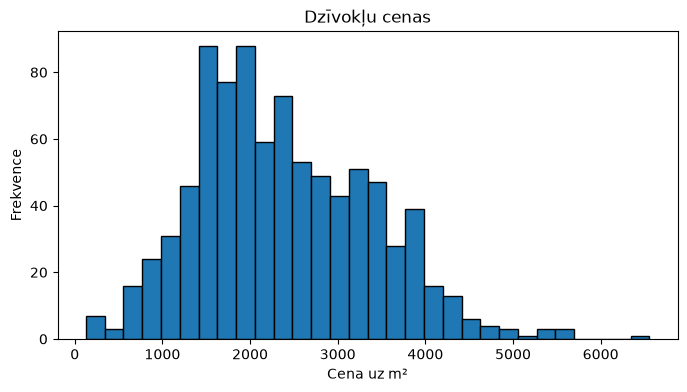

In [23]:
# apskatīsimies histogrammu par cenu uz m²
plt.figure(figsize=(8,4))
plt.hist(df["price_per_m2"], bins=30, edgecolor='black')
plt.xlabel('Cena uz m²')
plt.ylabel('Frekvence')
plt.title('Dzīvokļu cenas')
plt.show()

C:\Users\val-wd\AppData\Local\Temp\ipykernel_5700\793176482.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["price_per_m2"].dropna(), vert=False)


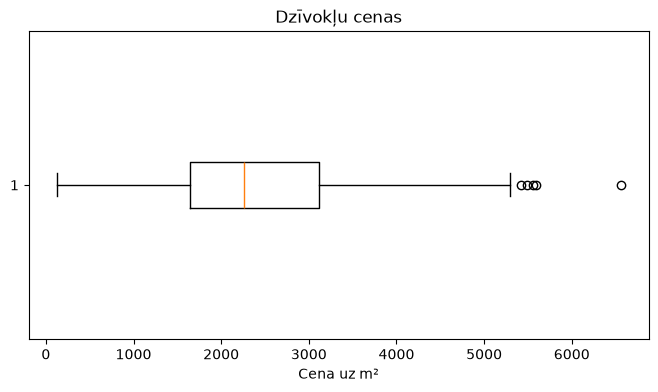

In [24]:
# histgroammas nav pilnīgi uzticamas jo var atšķirties atkarībā no izvēlētā bin skaita, 
# tāpēc varam izmantot arī boxplot vai arī kdeplot, kas ir smalkāks un parāda arī sadalījumu
# mūs tātad interesē kdeplot, kas labāk parāda sadalījumu, jo histogramma ir atkarīga no izvēlētā bin skaita

# attēlosim cenu uz m² sadalījumu ar boxplot
plt.figure(figsize=(8,4))
plt.boxplot(df["price_per_m2"].dropna(), vert=False)
plt.xlabel('Cena uz m²')
plt.title('Dzīvokļu cenas')
plt.show()

In [27]:
# let's plot kde plot
# we can use plotly
import plotly.express as px
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Histogram(x=df["price_per_m2"], nbinsx=100, name="Cena uz m²"))
fig.update_layout(title="Dzīvokļu cenas", xaxis_title="Cena uz m²", yaxis_title="Frekvence")
fig.show()


In [28]:
# šis ir tikai tur kur īres gadījumā, kad ir norādīts periods, piemēram, "€ 1 200 / month"
# monthly_df = (df[df["price_period"]=="month"]
#               .dropna(subset=["rooms","area_m2","price_eur","price_per_m2"])
#               .copy())
# print("Mēneša īres rindas:", len(monthly_df))

# affordable = monthly_df[
#     (monthly_df["rooms"]>=2) & (monthly_df["price_eur"]<=700)
# ].sort_values(["price_eur","area_m2"])
# display(affordable[["street","rooms","area_m2","price_eur","price_per_m2"]].head(15))
# display(monthly_df[["rooms","area_m2","price_eur","price_per_m2"]].describe().round(2))
# print("Vidējā cena:", round(monthly_df["price_eur"].mean(),2))
# print("Mediāna:", round(monthly_df["price_eur"].median(),2))

## 7. Pirmās vizualizācijas

**Histogramma** parāda nepārtraukta skaitliska mainīgā sadalījumu; **stabiņu diagramma** ir piemērota diskrētām kategorijām. Šeit skatām mēneša cenu sadalījumu un sludinājumu skaitu pēc istabu skaita.

In [ ]:
plt.figure(figsize=(9,5))
plt.hist(monthly_df["price_eur"], bins=30)
plt.xlabel("Mēneša īre (€)"); plt.ylabel("Sludinājumu skaits")
plt.title("Mēneša īres cenu sadalījums"); plt.tight_layout(); plt.show()

room_counts = monthly_df["rooms"].value_counts().sort_index()
plt.figure(figsize=(8,5))
plt.bar(room_counts.index.astype(str), room_counts.values)
plt.xlabel("Istabu skaits"); plt.ylabel("Sludinājumu skaits")
plt.title("Sludinājumi pēc istabu skaita"); plt.tight_layout(); plt.show()

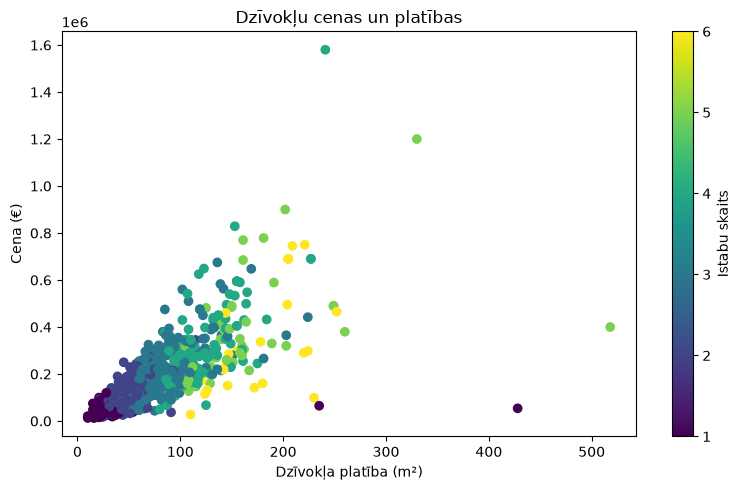

In [29]:
# uztaisīsim scatter plot, kur x ass būs dzīvokļa platība, y ass cena, un krāsa būs atkarīga no istabu skaita
plt.figure(figsize=(8,5))
plt.scatter(df["area_m2"], df["price_eur"], c=df["rooms"], cmap="viridis")
plt.xlabel("Dzīvokļa platība (m²)")
plt.ylabel("Cena (€)")
plt.title("Dzīvokļu cenas un platības")
plt.colorbar(label="Istabu skaits")
plt.tight_layout()
plt.show()


In [32]:
# kādas mums ir kolonas?
df.columns

Index(['description', 'url', 'street', 'rooms', 'area_m2', 'floor',
       'building_series', 'price_per_m2_raw', 'price_raw', 'price_per_m2',
       'price_eur', 'price_period', 'floor_number', 'building_floors',
       'is_ground_floor', 'is_top_floor', 'calculated_price_per_m2',
       'price_m2_difference'],
      dtype='str')

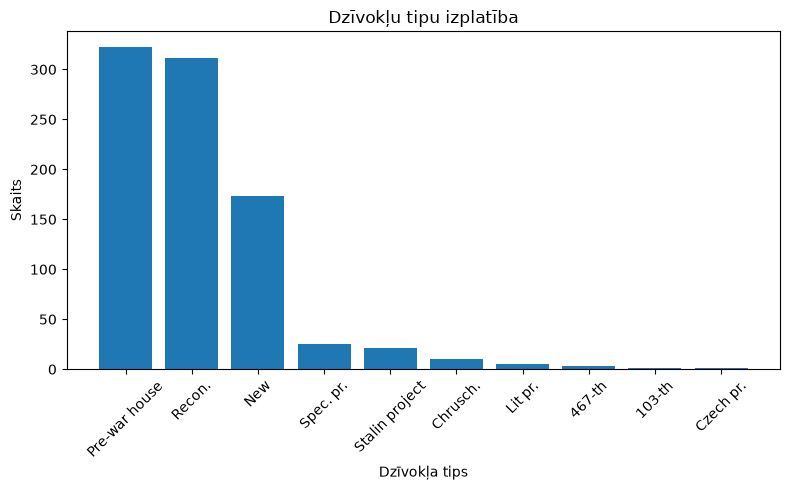

In [33]:
# apskatamies dzīvokļu tipus kā stabiņus
plt.figure(figsize=(8,5))
plt.bar(df["building_series"].value_counts().index, df["building_series"].value_counts().values)
plt.xlabel("Dzīvokļa tips")
plt.ylabel("Skaits")
plt.title("Dzīvokļu tipu izplatība")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
# izrēķināsim korelāciju starp cenu un platību
correlation = df["area_m2"].corr(df["price_eur"])
print("Korelācija starp cenu un platību:", round(correlation, 2))

Korelācija starp cenu un platību: 0.53


## 8. `groupby()` un `agg()`

`groupby()` domāšanas modelis ir **split → apply → combine**: sadalām rindas grupās, katrai grupai aprēķinām statistiku un apvienojam rezultātus. Ar `agg()` vienlaikus iegūstam sludinājumu skaitu, mediānu, vidējo cenu, platību un `€/m²`.

In [34]:
df.head()

,description,url,street,rooms,area_m2,floor,building_series,price_per_m2_raw,price_raw,price_per_m2,price_eur,price_period,floor_number,building_floors,is_ground_floor,is_top_floor,calculated_price_per_m2,price_m2_difference
0,"Vieta, vieta, vieta. Tiek pārdots dzīvoklis ēk...",https://www.ss.com/msg/en/real-estate/flats/ri...,Brivibas 19,4,94,5/6,Pre-war house,"2,122 €","199,500 €",2122,199500,unknown,5,6,False,False,2122.340426,0.340426
1,Balkons. Renovētā ēkā Rīgas centrā pārdod 4 is...,https://www.ss.com/msg/en/real-estate/flats/ri...,Stabu 16,4,109,4/6,Recon.,"1,702 €","185,500 €",1702,185500,unknown,4,6,False,False,1701.834862,0.165138
2,Trīsistabu dzīvoklis skaisti renovētā ēkā\r\n\...,https://www.ss.com/msg/en/real-estate/flats/ri...,Matisa 101,3,37,1/3,Recon.,"2,288 €","84,640 €",2288,84640,unknown,1,3,True,False,2287.567568,0.432432
3,Piedāvājumā dzīvokļi unikālā koncepta projektā...,https://www.ss.com/msg/en/real-estate/flats/ri...,Gertrudes 110,3,49,3/5,Recon.,"1,568 €","76,850 €",1568,76850,unknown,3,5,False,False,1568.367347,0.367347
4,Pārdod gaišu un plašu 2 istabu dzīvokli (54 m²...,https://www.ss.com/msg/en/real-estate/flats/ri...,Valdemara 147k-1,2,54,5/5,Spec. pr.,"1,850 €","99,900 €",1850,99900,unknown,5,5,False,True,1850.0,0.0


,listings,median_price,mean_price,mean_area,mean_price_m2
rooms,,,,,
1,123,52500.0,60401.11,33.30,2159.22
2,272,112530.0,120038.96,48.77,2480.26
3,265,184000.0,202522.17,81.54,2456.58
4,131,254610.0,294520.03,114.97,2485.69
5,48,312200.0,364712.58,160.56,2269.92
6,23,290000.0,345057.39,176.61,1864.61


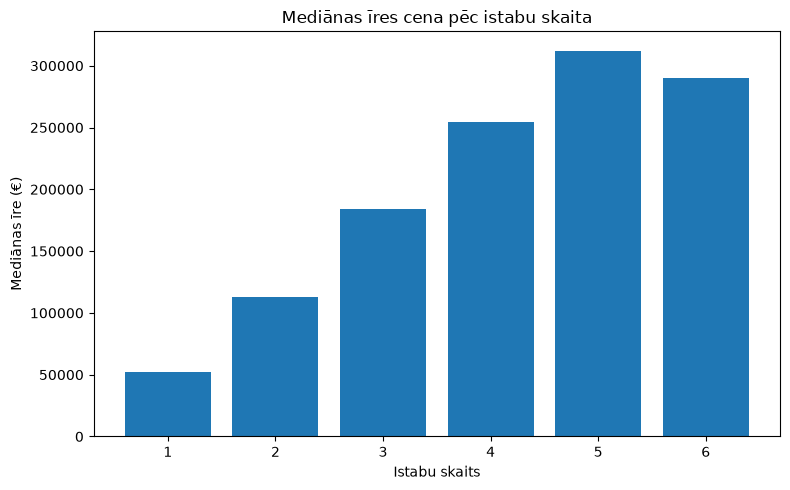

In [35]:
room_stats = (df.groupby("rooms")
    .agg(listings=("price_eur","count"),
         median_price=("price_eur","median"),
         mean_price=("price_eur","mean"),
         mean_area=("area_m2","mean"),
         mean_price_m2=("price_per_m2","mean"))
    .sort_index())
display(room_stats.round(2))

plt.figure(figsize=(8,5))
plt.bar(room_stats.index.astype(str), room_stats["median_price"])
plt.xlabel("Istabu skaits"); plt.ylabel("Mediānas īre (€)")
plt.title("Mediānas īres cena pēc istabu skaita"); plt.tight_layout(); plt.show()

## 9. Grupēšana pēc ēkas tipa

Kategorijām salīdzinām `€/m²`, bet vienmēr skatām arī grupas lielumu: viena sludinājuma “mediāna” ir daudz mazāk uzticama par simtiem novērojumu. Gariem nosaukumiem izmantojam horizontālu stabiņu diagrammu.

,listings,median_price_m2,mean_price_m2,mean_area
building_series,,,,
Chrusch.,10,1426.5,1499.5,43.20
Lit pr.,5,1480.0,1379.0,56.40
467-th,3,1700.0,1629.0,60.67
Czech pr.,1,1707.0,1707.0,41.00
Spec. pr.,25,1707.0,1678.24,146.56
Pre-war house,322,1761.0,1842.55,78.73
103-th,1,1848.0,1848.0,46.00
Stalin project,21,1909.0,1830.9,92.24
Recon.,311,2580.0,2674.85,72.25


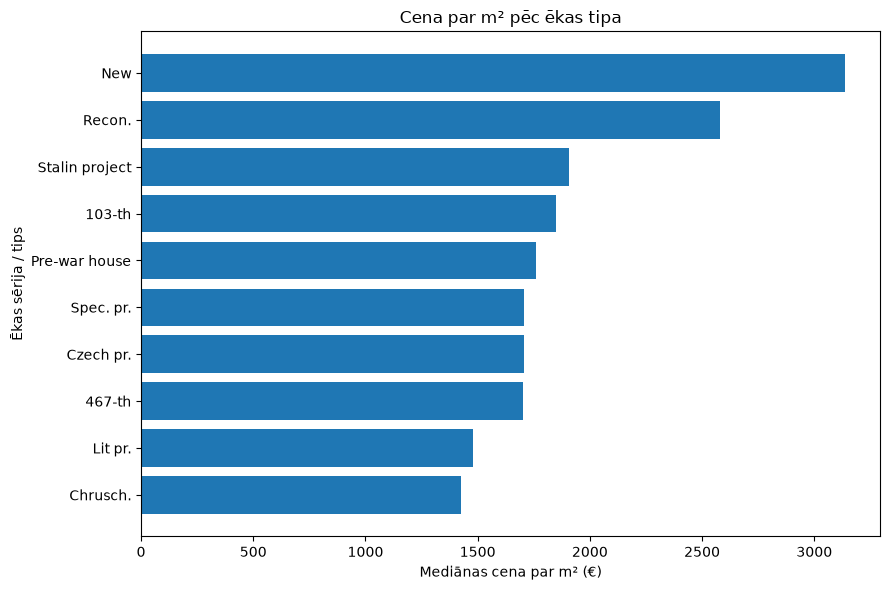

In [36]:
series_stats = (df.groupby("building_series", observed=True)
    .agg(listings=("price_per_m2","count"),
         median_price_m2=("price_per_m2","median"),
         mean_price_m2=("price_per_m2","mean"),
         mean_area=("area_m2","mean"))
    .sort_values("median_price_m2"))
display(series_stats.round(2))

plt.figure(figsize=(9,6))
plt.barh(series_stats.index.astype(str), series_stats["median_price_m2"])
plt.xlabel("Mediānas cena par m² (€)"); plt.ylabel("Ēkas sērija / tips")
plt.title("Cena par m² pēc ēkas tipa"); plt.tight_layout(); plt.show()

## 10. Scatter plot, korelācija un boxplot

Scatter plot palīdz ieraudzīt saistību starp platību un cenu. `corr()` apkopo lineāras saistības, bet **korelācija nepierāda cēloņsakarību**. Boxplot savukārt rāda mediānu, kvartiles, izkliedi un potenciālus outlier, tādēļ grupu salīdzinājumam saglabā vairāk informācijas nekā viena vidējā vērtība.

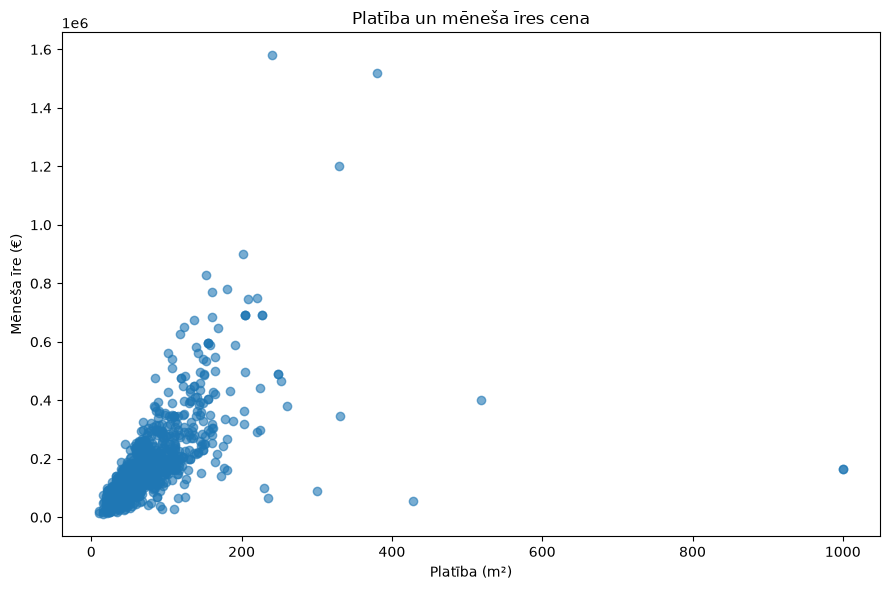

,rooms,area_m2,price_eur,price_per_m2,floor_number,building_floors
rooms,1.000,0.757,0.597,-0.001,0.121,0.098
area_m2,0.757,1.000,0.535,-0.083,0.127,0.070
price_eur,0.597,0.535,1.000,0.536,0.238,0.214
price_per_m2,-0.001,-0.083,0.536,1.000,0.163,0.208
floor_number,0.121,0.127,0.238,0.163,1.000,0.604
building_floors,0.098,0.070,0.214,0.208,0.604,1.000


<Figure size 900x600 with 0 Axes>

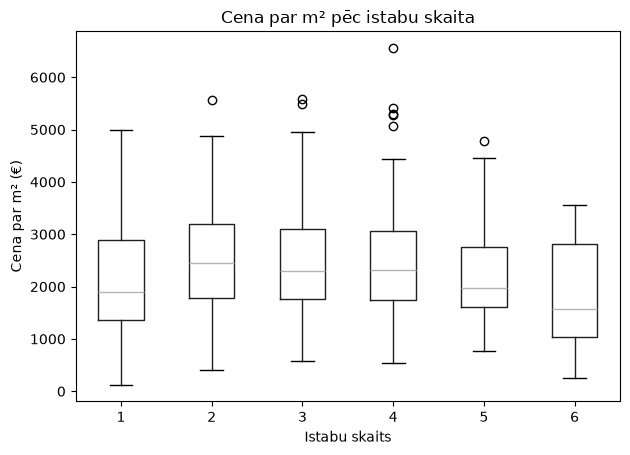

In [37]:
plt.figure(figsize=(9,6))
plt.scatter(df["area_m2"], df["price_eur"], alpha=0.6)
plt.xlabel("Platība (m²)"); plt.ylabel("Mēneša īre (€)")
plt.title("Platība un mēneša īres cena"); plt.tight_layout(); plt.show()

corr_cols = ["rooms","area_m2","price_eur","price_per_m2","floor_number","building_floors"]
display(df[corr_cols].astype(float).corr().round(3))

plt.figure(figsize=(9,6))
df.boxplot(column="price_per_m2", by="rooms", grid=False)
plt.xlabel("Istabu skaits"); plt.ylabel("Cena par m² (€)")
plt.title("Cena par m² pēc istabu skaita"); plt.suptitle("")
plt.tight_layout(); plt.show()

## 11. Praktisks jautājums un neparasti novērojumi

Meklējam 2 istabu dzīvokļus ar vismaz 40 m² un īri līdz 700 €, kārtojot pēc `€/m²`. Pēc tam apskatām dārgākos ierakstus.

**Outlier nav automātiski kļūda.** Tas var būt luksusa objekts, atšķirīgs piedāvājuma tips vai scraping problēma; to pārbauda, atverot avota URL.

In [ ]:
choice = (monthly_df[
    (monthly_df["rooms"]==2) &
    (monthly_df["area_m2"]>=40) &
    (monthly_df["price_eur"]<=700)
].sort_values(["price_per_m2","price_eur"]))
cols = ["street","area_m2","floor","building_series","price_eur","price_per_m2","url"]
display(choice[cols].head(20))

print("Augstākās cenas par m²:")
display(monthly_df.nlargest(10,"price_per_m2")[
    ["street","rooms","area_m2","price_eur","price_per_m2","url"]])

## 12. Reproducējama tīrīšanas funkcija un eksports

Lekcijā tīrīšanu veicām pa soļiem, lai redzētu katras darbības nozīmi. Automatizācijā šos soļus apvieno funkcijā, kuru var atkārtoti palaist nākamajam scraping rezultātam. Attīrīto kopu saglabājam atsevišķi no neapstrādātajiem datiem.

In [ ]:
def clean_apartments(source_df):
    x = source_df.rename(columns={
        "Street":"street","R.":"rooms","m²":"area_m2","Floor":"floor",
        "Series":"building_series","Price, m2":"price_per_m2_raw","Price":"price_raw"
    }).copy()
    x["rooms"] = pd.to_numeric(x["rooms"],errors="coerce").astype("Int64")
    x["area_m2"] = pd.to_numeric(x["area_m2"],errors="coerce")
    x["price_per_m2"] = euro_number(x["price_per_m2_raw"])
    x["price_eur"] = euro_number(x["price_raw"])
    x["price_period"] = x["price_raw"].apply(price_period)
    p = x["floor"].astype("string").str.extract(
        r"(?P<floor_number>\d+)\s*/\s*(?P<building_floors>\d+)")
    x["floor_number"] = pd.to_numeric(p["floor_number"],errors="coerce").astype("Int64")
    x["building_floors"] = pd.to_numeric(p["building_floors"],errors="coerce").astype("Int64")
    x["is_ground_floor"] = x["floor_number"].eq(1)
    x["is_top_floor"] = x["floor_number"].eq(x["building_floors"])
    x["building_series"] = x["building_series"].astype("string").str.strip().astype("category")
    x = x.drop_duplicates(subset=["url"], keep="first").copy()
    x["calculated_price_per_m2"] = x["price_eur"]/x["area_m2"]
    return x

clean_df = clean_apartments(raw_df)
OUTPUT = Path("apartments_clean.csv")
clean_df.to_csv(OUTPUT, index=False, encoding="utf-8")
print("Saglabāts:", OUTPUT.resolve(), "| rindas:", len(clean_df))

## 13. Praktiskie uzdevumi

1. Atrodiet platības mediānu un piecus lētākos sludinājumus.
2. Saskaitiet sludinājumus pēc istabu skaita.
3. Aprēķiniet mediānas īri pēc istabu skaita.
4. Aprēķiniet mediānas `€/m²` pēc ēkas tipa.
5. Uzzīmējiet platības histogrammu.
6. Uzzīmējiet mediānas īri pēc istabu skaita.
7. Izveidojiet scatter plot: platība pret cenu.
8. Atrodiet 10 augstākās `€/m²` vērtības.
9. Definējiet savus atlases kritērijus un atrodiet 5 kandidātus.

Šūnā zemāk ir komentēti sākumpunkti, tādēļ **Run All** paliek drošs.

In [ ]:
# monthly_df["area_m2"].median()
# monthly_df.nsmallest(5, "price_eur")
# monthly_df["rooms"].value_counts().sort_index()

# my_choice = monthly_df[
#     (monthly_df["rooms"] >= 2)
#     & (monthly_df["area_m2"] >= 45)
#     & (monthly_df["price_eur"] <= 750)
# ]
# display(my_choice.sort_values("price_per_m2").head(5))

## 14. Bonuss — Plotly

Matplotlib paliek lekcijas galvenā bibliotēka. Plotly īsi demonstrē interaktīvu scatter plot ar hover informāciju, zoom un krāsu pēc istabu skaita.

In [38]:
import plotly.express as px
plot_df = df.dropna(subset=["area_m2","price_eur","rooms"]).copy()
plot_df["rooms_label"] = plot_df["rooms"].astype("string")
fig = px.scatter(
    plot_df, x="area_m2", y="price_eur", color="rooms_label",
    hover_data=["street","building_series","price_per_m2"],
    labels={"area_m2":"Platība (m²)","price_eur":"Mēneša īre (€)",
            "rooms_label":"Istabas"},
    title="Rīgas centra dzīvokļi: platība un mēneša īres cena")
fig.show()

## Kopsavilkums

**SS.com → scraping → CSV → Pandas → tīrīšana → analīze → vizualizācija → secinājumi → tīrs CSV**

Svarīgākais: analīze sākas ar datu apskati; skaitlis bez mērvienības var būt kļūdaini interpretējams; `groupby()` + `agg()` ir centrāls biznesa analīzes paņēmiens; dažādi grafiki atbild uz dažādiem jautājumiem; outlier nav automātiski kļūda; tīrīšanas loģiku vērts padarīt atkārtojamu.

In [40]:
# ielādejam visu rīgu
riga = pd.read_excel("../../data/ss_flats_riga_all_sell_20260916_211916.xlsx")
# izmērs
riga.shape

(2562, 8)

In [41]:
# head
riga.head()

,description,url,District,R.,m²,Floor,Series,Price
0,Meklējam jaunos saimniekus ļoti plašam un mājī...,https://www.ss.com/msg/en/real-estate/flats/ri...,Ziepniekkalns Kaplavas 5,3,114,4/5,New,"169,000 €"
1,"Stilīgs, ērts mājokļis un dzīves telpa urbānaj...",https://www.ss.com/msg/en/real-estate/flats/ri...,Agenskalns M. Nometnu 24,1,37,5/5,Recon.,"109,200 €"
2,Divistabu dzīvoklis ar savu zaļo zonu no guļam...,https://www.ss.com/msg/en/real-estate/flats/ri...,Centre Matisa 101,2,27,1/3,Recon.,"62,790 €"
3,Pārdod vienistabas dzīvokli ar kosmētisko remo...,https://www.ss.com/msg/en/real-estate/flats/ri...,Plyavnieki Rudens 6,1,35,1/9,602-th,"48,000 €"
4,Dzīvoklis atrodas slēgtā un drošā dzīvojamajā ...,https://www.ss.com/msg/en/real-estate/flats/ri...,Yugla Juglas 10,4,138,7/9,New,"228,000 €"


In [42]:
# describe
riga.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
description,2562,2335,Attīstītājs piedāvā iegādāties dzīvokli pilnīb...,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
url,2562,2562,https://www.ss.com/msg/en/real-estate/flats/ri...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,2562,1747,Vecriga Pasta 6,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
R.,2562,7,2,938,NaN,NaN,NaN,NaN,NaN,NaN,NaN
m²,2562.0,NaN,NaN,NaN,67.898126,52.228601,10.0,41.0,56.0,78.0,1000.0
Floor,2562,126,5/5,194,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Series,2562,15,New,647,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,2562,1207,"60,000 €",25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
